In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set(style="whitegrid")

In [27]:
df = pd.read_csv('c:\\Users\\yashv\\Downloads\\employee dataset.csv')
df.head()

,table id,name,phone number,Location,Emp. Group,Function,Gender,Tenure,Tenure Grp.,Experience (YY.MM),Marital Status,Age in YY.,Hiring Source,Promoted/Non Promoted,Job Role Match,Stay/Left
0,1,sid,9876544345,Delhi,B5,HR,Female,4.60,1-3,9.41,Single,25.55,Agency,Non Promoted,No,Stay
1,2,sid,9876544345,Pune,B1,Operation,Male,0.25,>5,21.61,Single,28.56,Direct,Promoted,No,Stay
2,3,sid,9876544345,Kolkata,B6,Operation,Male,2.87,>5,4.04,Single,22.47,Referral,Non Promoted,No,Left
3,4,sid,9876544345,Lucknow,B5,HR,Female,4.27,>5,14.58,Marr.,44.56,Referral,Non Promoted,No,Stay
4,5,sid,9876544345,Bangalore,B4,HR,Male,1.21,3-5,4.41,Marr.,55.70,Direct,Promoted,Yes,Stay


In [28]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (1000, 16)


In [29]:
df.columns = [col.strip().lower().replace(' ', '_').replace('.', '_').replace('/', '_') for col in df.columns]

In [30]:
df['attrition'] = df['stay_left'].apply(lambda x: 1 if x.lower() == 'left' else 0)
print("\nAttrition distribution:")
print(df['attrition'].value_counts())
print(f"Attrition rate: {df['attrition'].mean()*100:.2f}%")


Attrition distribution:
attrition
0    750
1    250
Name: count, dtype: int64
Attrition rate: 25.00%


In [31]:
cols_to_drop = ['table_id', 'name', 'phone_number', 'stay_left']
features_df = df.drop(cols_to_drop + ['attrition'], axis=1, errors='ignore')
features_df.head()

,location,emp__group,function,gender,tenure,tenure_grp_,experience_(yy_mm),marital_status,age_in_yy_,hiring_source,promoted_non_promoted,job_role_match
0,Delhi,B5,HR,Female,4.60,1-3,9.41,Single,25.55,Agency,Non Promoted,No
1,Pune,B1,Operation,Male,0.25,>5,21.61,Single,28.56,Direct,Promoted,No
2,Kolkata,B6,Operation,Male,2.87,>5,4.04,Single,22.47,Referral,Non Promoted,No
3,Lucknow,B5,HR,Female,4.27,>5,14.58,Marr.,44.56,Referral,Non Promoted,No
4,Bangalore,B4,HR,Male,1.21,3-5,4.41,Marr.,55.70,Direct,Promoted,Yes


In [32]:
categorical_cols = features_df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = features_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")

Categorical features: 9
Numerical features: 3


In [33]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [34]:
X = features_df
y = df['attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (750, 12)
Testing set: (250, 12)


In [47]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure',
                                                   'experience_(yy_mm)',
                                                   'age_in_yy_']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['location', 'emp__group',
                                                   'function', 'gender',
                                                   'tenure_grp_',
                                                   'marital_status',
                                                   'hiring_source',
                                                   'promoted_non_promoted',
                                                   'job_role_match'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [36]:
lr_predictions = lr_pipeline.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.7440

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.99      0.85       188
           1       0.00      0.00      0.00        62

    accuracy                           0.74       250
   macro avg       0.38      0.49      0.43       250
weighted avg       0.56      0.74      0.64       250



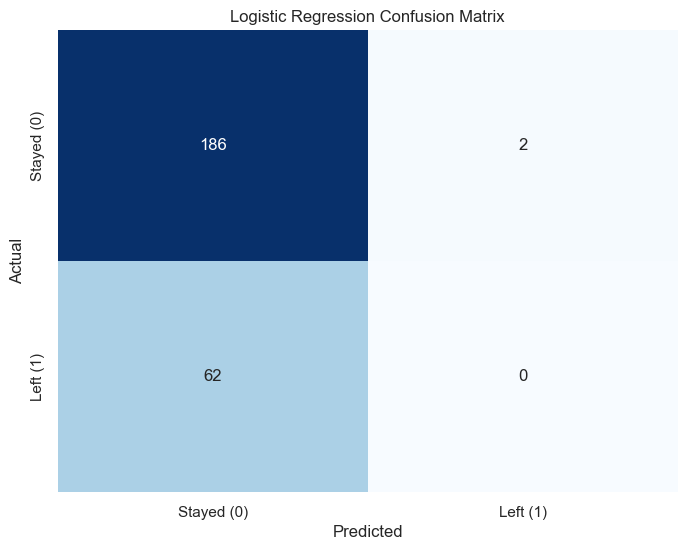

In [37]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks([0.5, 1.5], ['Stayed (0)', 'Left (1)'])
plt.yticks([0.5, 1.5], ['Stayed (0)', 'Left (1)'])
plt.show()

In [38]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure',
                                                   'experience_(yy_mm)',
                                                   'age_in_yy_']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['location', 'emp__group',
                                                   'function', 'gender',
                                                   'tenure_grp_',
                                                   'marital_status',
                                                   'hiring_source',
                                                   'promoted_non_promoted',
                                                   'job_role_match'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [39]:
dt_predictions = dt_pipeline.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.5560

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.66      0.69       188
           1       0.19      0.24      0.21        62

    accuracy                           0.56       250
   macro avg       0.46      0.45      0.45       250
weighted avg       0.59      0.56      0.57       250



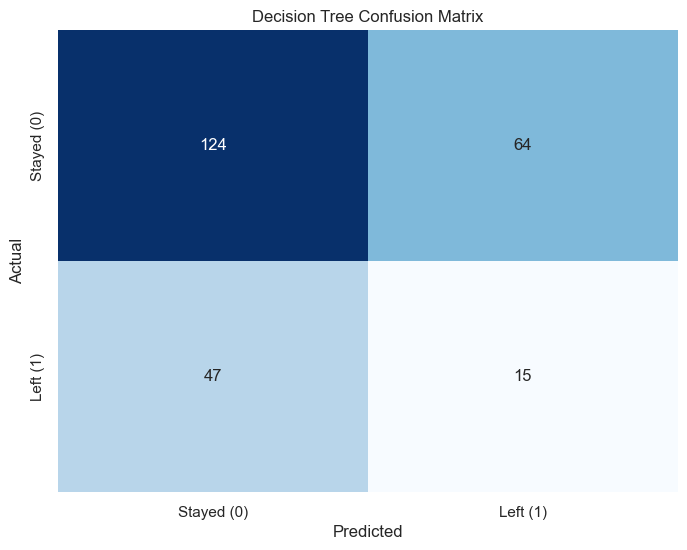

In [40]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks([0.5, 1.5], ['Stayed (0)', 'Left (1)'])
plt.yticks([0.5, 1.5], ['Stayed (0)', 'Left (1)'])
plt.show()

In [41]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure',
                                                   'experience_(yy_mm)',
                                                   'age_in_yy_']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['location', 'emp__group',
                                                   'function', 'gender',
                                                   'tenure_grp_',
                                                   'marital_status',
                                                   'hiring_source',
                                                   'promoted_non_promoted',
                                                   'job_role_match'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [42]:
rf_predictions = rf_pipeline.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7320

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.97      0.85       188
           1       0.00      0.00      0.00        62

    accuracy                           0.73       250
   macro avg       0.37      0.49      0.42       250
weighted avg       0.56      0.73      0.64       250



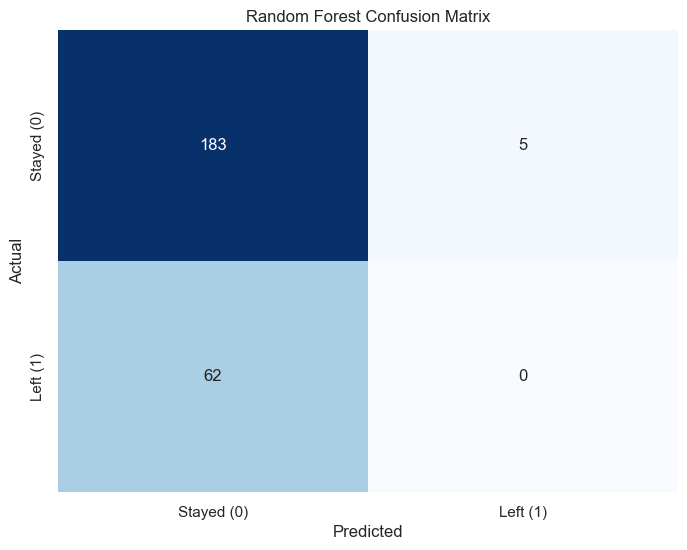

In [43]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks([0.5, 1.5], ['Stayed (0)', 'Left (1)'])
plt.yticks([0.5, 1.5], ['Stayed (0)', 'Left (1)'])
plt.show()


Model Comparison:
Decision Tree Accuracy: 0.5560
Random Forest Accuracy: 0.7320
Logistic Regression Accuracy: 0.7440


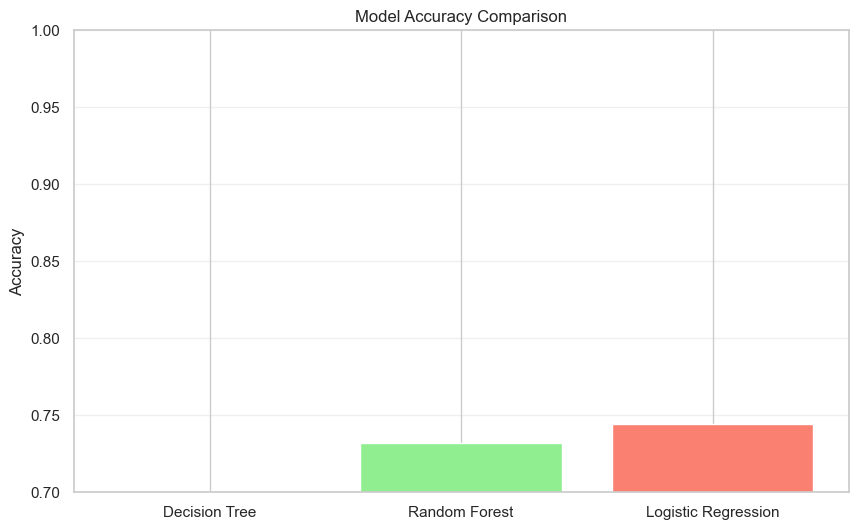

In [48]:
print("\nModel Comparison:")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

plt.figure(figsize=(10, 6))
model_names = ['Decision Tree', 'Random Forest', 'Logistic Regression']
accuracies = [dt_accuracy, rf_accuracy, lr_accuracy]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.bar(model_names, accuracies, color=colors)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.grid(axis='y', alpha=0.3)

In [45]:
all_accuracies = {'Decision Tree': dt_accuracy, 
                 'Random Forest': rf_accuracy, 
                 'Logistic Regression': lr_accuracy}
best_model = max(all_accuracies.items(), key=lambda x: x[1])[0]
print(f"Best Model: {best_model}")

Best Model: Logistic Regression
